In [68]:
import pandas as pd
import numpy as np 
import yfinance as yf 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.ensemble import RandomForestRegressor


In [69]:
tesla=yf.Ticker('TSLA')
df=tesla.history(period='1mo')

In [70]:
df.isnull().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [71]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,22.000000,22.000000,22.000000,22.000000,2.200000e+01,22.0,22.0
mean,414.261819,420.802730,405.589547,413.423637,4.685639e+07,0.0,0.0
std,15.627755,14.462678,17.839239,16.310360,8.166553e+06,0.0,0.0
min,388.279999,397.089996,380.149994,381.589996,3.243500e+07,0.0,0.0
25%,401.937500,408.114998,389.849998,401.394989,4.377590e+07,0.0,0.0
50%,415.294998,421.460007,406.745010,413.514999,4.530950e+07,0.0,0.0
75%,422.547508,431.032509,416.870003,423.729996,4.889685e+07,0.0,0.0
max,442.890015,445.600006,436.299988,442.100006,6.351450e+07,0.0,0.0


In [72]:
df=df.drop(['Dividends','Stock Splits'],axis=1)

In [73]:
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2026-05-19 00:00:00-04:00,403.160004,405.630005,393.630005,404.109985,46500600
2026-05-20 00:00:00-04:00,407.600006,417.459991,406.390015,417.260010,45294700
2026-05-21 00:00:00-04:00,422.179993,426.950012,412.899994,417.850006,42636900
2026-05-22 00:00:00-04:00,422.670013,431.510010,420.510010,426.010010,46104700
2026-05-26 00:00:00-04:00,430.260010,435.200012,426.119995,433.589996,45658900


In [74]:
df['Next_Day_Closing']=df['Close'].shift(-1)

In [75]:
df=df.dropna()
x = df[['Open','High','Low','Close','Volume']]
y = df['Next_Day_Closing']

In [76]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.20)

In [77]:
lr=LinearRegression()


In [78]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[0.25,0.22,0.24,0.22,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['Open','High','Low','Close','Volume']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,23.91
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [79]:
y_pred_lr=lr.predict(x_test)

In [80]:
mse_lr=mean_squared_error(y_test,y_pred_lr)
r2_lr=r2_score(y_test,y_pred_lr)

In [81]:
print("MSE_IR",mse)
print("R2_Score_IR",r2)

MSE_IR 156.67786996883297
R2_Score_IR -1.245837653968192


In [82]:
rf=RandomForestRegressor()
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [83]:
y_pred_rf=rf.predict(x_test)

In [84]:
mse_rf=mean_squared_error(y_test,y_pred_rf)
r2_rf=r2_score(y_test,y_pred_rf)

In [85]:
print("MSE_RF",mse_rf)
print("R2_Score_RF",r2_rf)

MSE_RF 157.4896152689448
R2_Score_RF -1.2574732995177866


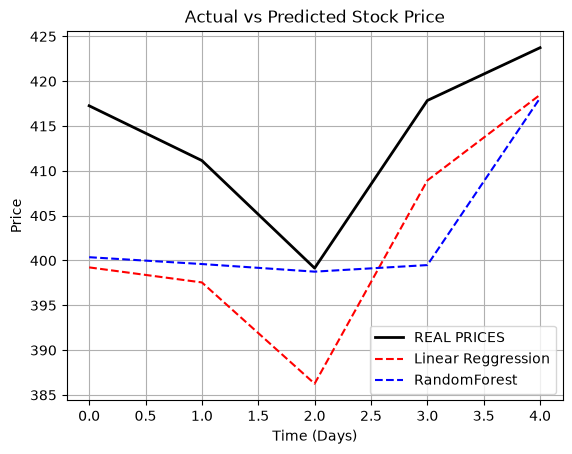

In [89]:
plt.Figure(figsize=(12,6))
plt.plot(y_test.values,label='REAL PRICES',color='black',linewidth=2)
plt.plot(y_pred_lr,label='Linear Reggression',color='red',linestyle='--')
plt.plot(y_pred_rf,label='RandomForest',color='blue',linestyle='--')
plt.title('Actual vs Predicted Stock Price')
plt.xlabel('Time (Days)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()